# Socioeconomic vs ผลเลือกตั้ง — จังหวัดลำปาง
ใช้ข้อมูลสภาพทั่วไปหมู่บ้านจาก DOPA (กรมการปกครอง) เป็น proxy เศรษฐสังคม
- **ประชากร** (ชาย/หญิง) ระดับหมู่บ้าน → รวมระดับตำบล/อำเภอ
- **จำนวนบ้านเรือน** → proxy ความหนาแน่น
- **ระยะทางถึงถนน** → proxy ความห่างไกล/ชนบท
- Join กับผลเลือกตั้งระดับหน่วย → วิเคราะห์ว่าพื้นที่ลักษณะไหนเลือกพรรคอะไร

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

matplotlib.rcParams['font.family'] = 'Tahoma'
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

CLEAN = Path('cleaned/')
OUT   = Path('socioeconomic_data/')
OUT.mkdir(exist_ok=True)

---
## 1. ดึงข้อมูลหมู่บ้านจาก DOPA (data.go.th)

In [2]:
DOPA_URL = (
    'https://catalog.dopa.go.th/dataset/705402d4-2715-4ece-9166-22b54c6c3476'
    '/resource/7951cf97-32fa-4d88-944c-2f7de31885fc/download/.json'
)

r = requests.get(DOPA_URL, timeout=30)
raw = r.json()

dopa = pd.DataFrame(raw)
print(f'หมู่บ้านทั้งหมด: {len(dopa):,} แห่ง')
print(f'คอลัมน์: {list(dopa.columns)[:10]} ...')
dopa.head(3)

หมู่บ้านทั้งหมด: 1,041 แห่ง
คอลัมน์: ['pcode', 'pname', 'tname', 'acode', 'aname', 'tcode', 'mcode', 'mname', 'oct_side15_lat', 'oct_side15_lon'] ...


,pcode,pname,tname,acode,aname,tcode,mcode,mname,oct_side15_lat,oct_side15_lon,...,oct_side15_dam,oct_side15_dam_name,oct_side15_reservoir,oct_side15_reservoir_name,oct_side15_weir,oct_side15_weir_name,oct_side15_housing,oct_side15_housing_total,oct_side15_condos,oct_side15_condos_total
0,52,ลำปาง,เวียงเหนือ,5201,เมืองลำปาง,52010100,52010150,สามดวงสามัคคี,18.29899114931232,99.48194816708565,...,0,,0,,0,,0,,0,
1,52,ลำปาง,เวียงเหนือ,5201,เมืองลำปาง,52010100,52010151,ประตูม้า,18.306467724545183,99.51048821210861,...,0,,0,,0,,0,,0,
2,52,ลำปาง,เวียงเหนือ,5201,เมืองลำปาง,52010100,52010152,ศรีล้อม-แสงเมืองมา,18.296169524114024,99.50343266129494,...,0,,0,,0,,0,,0,


## 2. เลือกและทำความสะอาดฟิลด์ที่ต้องการ

In [3]:
cols = {
    'aname': 'district',
    'tname': 'sub-district',
    'mname': 'village_name',
    'mcode': 'village_code',
    'oct_side15_lat':      'latitude',
    'oct_side15_lon':      'longitude',
    'oct_side15_men':      'pop_male',
    'oct_side15_wmen':     'pop_female',
    'oct_side15_house':    'households',
    'oct_side15_distance': 'dist_to_center_km',
    'oct_side15_road':     'has_road',
    'oct_side15_road_distance': 'dist_to_road_km',
    'oct_side15_power':    'has_electricity',
    'oct_side15_dam':      'has_dam',
    'oct_side15_mountain': 'is_mountain',
}

df = dopa[list(cols.keys())].rename(columns=cols).copy()

# แปลงตัวเลข
num_cols = ['pop_male','pop_female','households','dist_to_center_km',
            'dist_to_road_km','has_road','has_electricity','has_dam','is_mountain']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df['pop_total'] = df['pop_male'].fillna(0) + df['pop_female'].fillna(0)
df['latitude']  = pd.to_numeric(df['latitude'],  errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')

# แก้ชื่ออำเภอให้ตรงกับ election data
district_fix = {
    'เมืองลำปาง': 'เมืองลำปาง',
}

print('shape:', df.shape)
print('null pop_total:', df['pop_total'].isna().sum())
df.head(3)

shape: (1041, 16)
null pop_total: 0


,district,sub-district,village_name,village_code,latitude,longitude,pop_male,pop_female,households,dist_to_center_km,has_road,dist_to_road_km,has_electricity,has_dam,is_mountain,pop_total
0,เมืองลำปาง,เวียงเหนือ,สามดวงสามัคคี,52010150,18.298991,99.481948,161.0,182.0,153.0,3.0,1,NaN,0,0,0,343.0
1,เมืองลำปาง,เวียงเหนือ,ประตูม้า,52010151,18.306468,99.510488,183.0,215.0,170.0,2.5,0,0.4,0,0,0,398.0
2,เมืองลำปาง,เวียงเหนือ,ศรีล้อม-แสงเมืองมา,52010152,18.296170,99.503433,147.0,212.0,213.0,0.9,0,1.5,0,0,0,359.0


## 3. รวมระดับตำบล (sub-district)

In [4]:
tambon = df.groupby(['district','sub-district']).agg(
    pop_total       = ('pop_total',      'sum'),
    households      = ('households',     'sum'),
    villages        = ('village_name',   'count'),
    has_electricity = ('has_electricity','mean'),
    is_mountain     = ('is_mountain',    'mean'),
    dist_center_avg = ('dist_to_center_km','mean'),
    lat             = ('latitude',       'mean'),
    lon             = ('longitude',      'mean'),
).reset_index()

tambon['pop_per_hh'] = tambon['pop_total'] / tambon['households'].replace(0, np.nan)

print('ตำบลทั้งหมด:', len(tambon))
print('อำเภอทั้งหมด:', tambon['district'].nunique())
tambon.head(5)

ตำบลทั้งหมด: 101
อำเภอทั้งหมด: 13


,district,sub-district,pop_total,households,villages,has_electricity,is_mountain,dist_center_avg,lat,lon,pop_per_hh
0,งาว,นาแก,2448.0,981.0,6,0.0,0.333333,11.250000,18.802248,99.919349,2.495413
1,งาว,บ้านร้อง,6970.0,2175.0,13,0.0,0.307692,40.615385,18.935338,99.877855,3.204598
2,งาว,บ้านหวด,3881.0,1425.0,6,0.0,0.333333,19.000000,18.627414,99.906845,2.723509
3,งาว,บ้านอ้อน,3303.0,1263.0,8,0.0,0.250000,13.950000,18.140670,99.891144,2.615202
4,งาว,บ้านแหง,5881.0,1968.0,8,0.0,0.000000,8.112500,18.759913,100.016621,2.988313


## 4. โหลด election data และรวมระดับตำบล

In [5]:
results = pd.read_csv(CLEAN / 'master_results_cleaned.csv')
summary = pd.read_csv(CLEAN / 'master_summary_cleaned.csv')

# คะแนนพรรคระดับตำบล (บช ในเขต)
r_bch = results[(results['type']=='บช') & (results['unit_number'] != -1)]

# หาพรรคอันดับ 1 ของแต่ละตำบล
tambon_score = (
    r_bch.groupby(['district','sub-district','name'])['score']
    .sum().reset_index()
)

# พรรคที่ชนะในแต่ละตำบล
winner = (
    tambon_score.sort_values('score', ascending=False)
    .groupby(['district','sub-district'])
    .first()
    .reset_index()
    .rename(columns={'name':'winner_party','score':'winner_score'})
)

# คะแนนรวมแต่ละตำบล
tambon_total = (
    r_bch.groupby(['district','sub-district'])['score']
    .sum().reset_index()
    .rename(columns={'score':'total_score'})
)

# summary ระดับตำบล (บช)
s_bch = summary[(summary['type']=='บช') & (summary['unit_number'] != -1)]
tambon_ballot = (
    s_bch.groupby(['district','sub-district'])
    [['total_ballots','valid_ballots','invalid_ballots','no_vote_ballots']]
    .sum().reset_index()
)
tambon_ballot['turnout_pct'] = (
    (tambon_ballot['total_ballots'] - tambon_ballot['no_vote_ballots'])
    / tambon_ballot['total_ballots'] * 100
)
tambon_ballot['invalid_pct'] = (
    tambon_ballot['invalid_ballots'] / tambon_ballot['total_ballots'] * 100
)

# join ทั้งหมด
election_tambon = winner.merge(tambon_total, on=['district','sub-district'], how='left')
election_tambon = election_tambon.merge(tambon_ballot, on=['district','sub-district'], how='left')
election_tambon['winner_pct'] = election_tambon['winner_score'] / election_tambon['total_score'] * 100

print('election ระดับตำบล:', election_tambon.shape)
election_tambon.head(5)

election ระดับตำบล: (36, 12)


,district,sub-district,winner_party,winner_score,total_score,total_ballots,valid_ballots,invalid_ballots,no_vote_ballots,turnout_pct,invalid_pct,winner_pct
0,งาว,นาแก,ประชาชน,448,1721,2740.0,1779.0,85.0,44.0,98.394161,3.102190,26.031377
1,งาว,บ้านร้อง,เพื่อไทย,649,2760,4840.0,2914.0,213.0,57.0,98.822314,4.400826,23.514493
2,งาว,บ้านหวด,ประชาชน,446,1542,3660.0,2034.0,178.0,56.0,98.469945,4.863388,28.923476
3,งาว,บ้านหวอด,รวมไทยสร้างชาติ,10,10,NaN,NaN,NaN,NaN,NaN,NaN,100.000000
4,งาว,บ้านอ้อน,เพื่อไทย,587,2233,3440.0,2113.0,146.0,46.0,98.662791,4.244186,26.287506


## 5. Merge DOPA + Election ระดับตำบล

In [6]:
merged = tambon.merge(election_tambon, on=['district','sub-district'], how='inner')
print(f'merged: {len(merged)} ตำบล')
print(f'match rate: {len(merged)}/{len(tambon)} ({len(merged)/len(tambon)*100:.1f}%)')
merged[['district','sub-district','pop_total','households','winner_party','winner_pct','turnout_pct']].head(8)

merged: 32 ตำบล
match rate: 32/101 (31.7%)


,district,sub-district,pop_total,households,winner_party,winner_pct,turnout_pct
0,งาว,นาแก,2448.0,981.0,ประชาชน,26.031377,98.394161
1,งาว,บ้านร้อง,6970.0,2175.0,เพื่อไทย,23.514493,98.822314
2,งาว,บ้านหวด,3881.0,1425.0,ประชาชน,28.923476,98.469945
3,งาว,บ้านอ้อน,3303.0,1263.0,เพื่อไทย,26.287506,98.662791
4,งาว,บ้านแหง,5881.0,1968.0,ประชาชน,22.942097,98.410042
5,งาว,บ้านโป่ง,6632.0,2354.0,เพื่อไทย,24.580713,98.543307
6,งาว,ปงเตา,6921.0,2240.0,เพื่อไทย,28.209256,98.835878
7,งาว,หลวงเหนือ,4199.0,2311.0,ประชาชน,29.188144,97.080745


---
## 6. พรรคที่ชนะ แยกตามขนาดประชากร

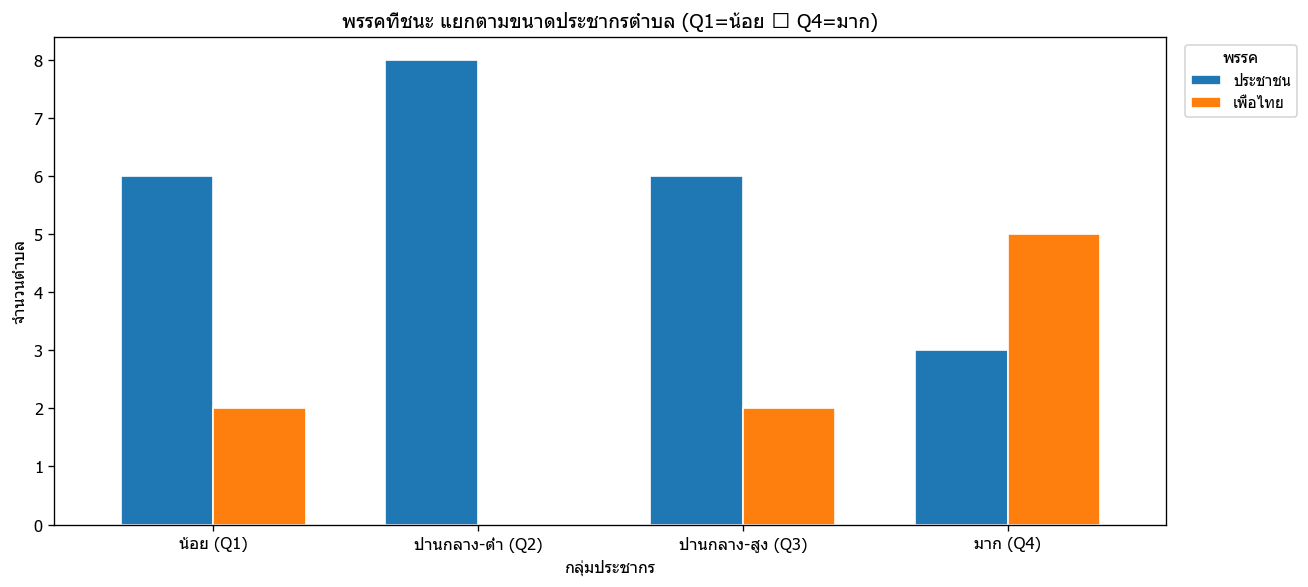

In [7]:
merged['pop_group'] = pd.qcut(
    merged['pop_total'], q=4,
    labels=['น้อย (Q1)','ปานกลาง-ต่ำ (Q2)','ปานกลาง-สูง (Q3)','มาก (Q4)']
)

pop_winner = (
    merged.groupby(['pop_group','winner_party'])
    .size().unstack(fill_value=0)
)

# เลือกเฉพาะพรรคที่ชนะบ่อย
top_parties = merged['winner_party'].value_counts().head(6).index
pop_winner = pop_winner[[c for c in top_parties if c in pop_winner.columns]]

fig, ax = plt.subplots(figsize=(11, 5))
pop_winner.plot(kind='bar', ax=ax, width=0.7, edgecolor='white')
ax.set_title('พรรคที่ชนะ แยกตามขนาดประชากรตำบล (Q1=น้อย → Q4=มาก)', fontsize=12)
ax.set_xlabel('กลุ่มประชากร')
ax.set_ylabel('จำนวนตำบล')
ax.legend(title='พรรค', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. พรรคที่ชนะ แยกตามความเป็นชนบท (ระยะทางถึงตัวอำเภอ)

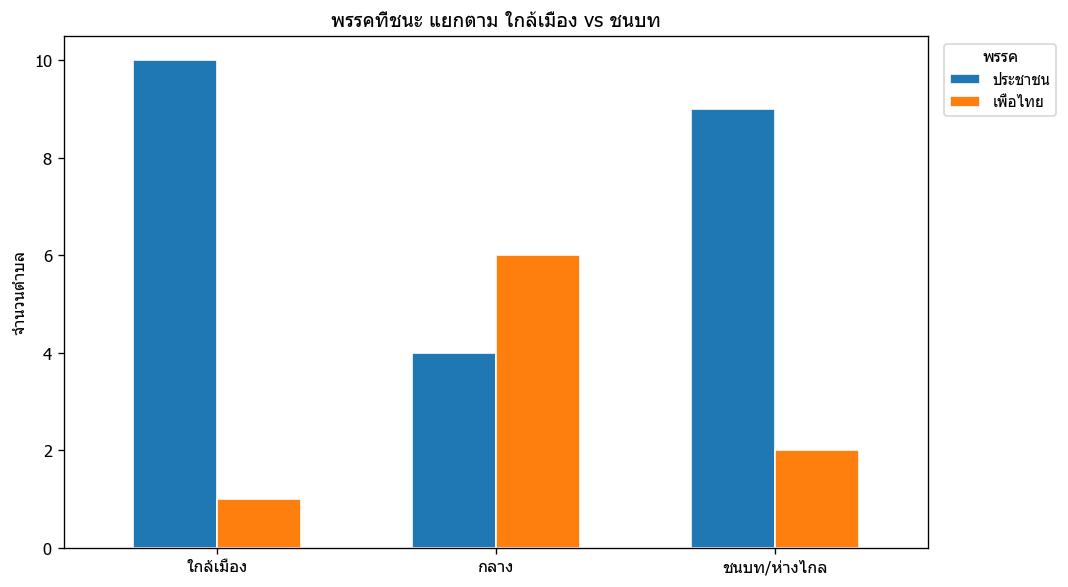

In [8]:
merged['rural_group'] = pd.qcut(
    merged['dist_center_avg'], q=3,
    labels=['ใกล้เมือง','กลาง','ชนบท/ห่างไกล']
)

rural_winner = (
    merged.groupby(['rural_group','winner_party'])
    .size().unstack(fill_value=0)
)
rural_winner = rural_winner[[c for c in top_parties if c in rural_winner.columns]]

fig, ax = plt.subplots(figsize=(9, 5))
rural_winner.plot(kind='bar', ax=ax, width=0.6, edgecolor='white')
ax.set_title('พรรคที่ชนะ แยกตาม ใกล้เมือง vs ชนบท', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('จำนวนตำบล')
ax.legend(title='พรรค', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Scatter: ประชากรต่อหลังคา vs % Turnout (สีตามพรรคที่ชนะ)

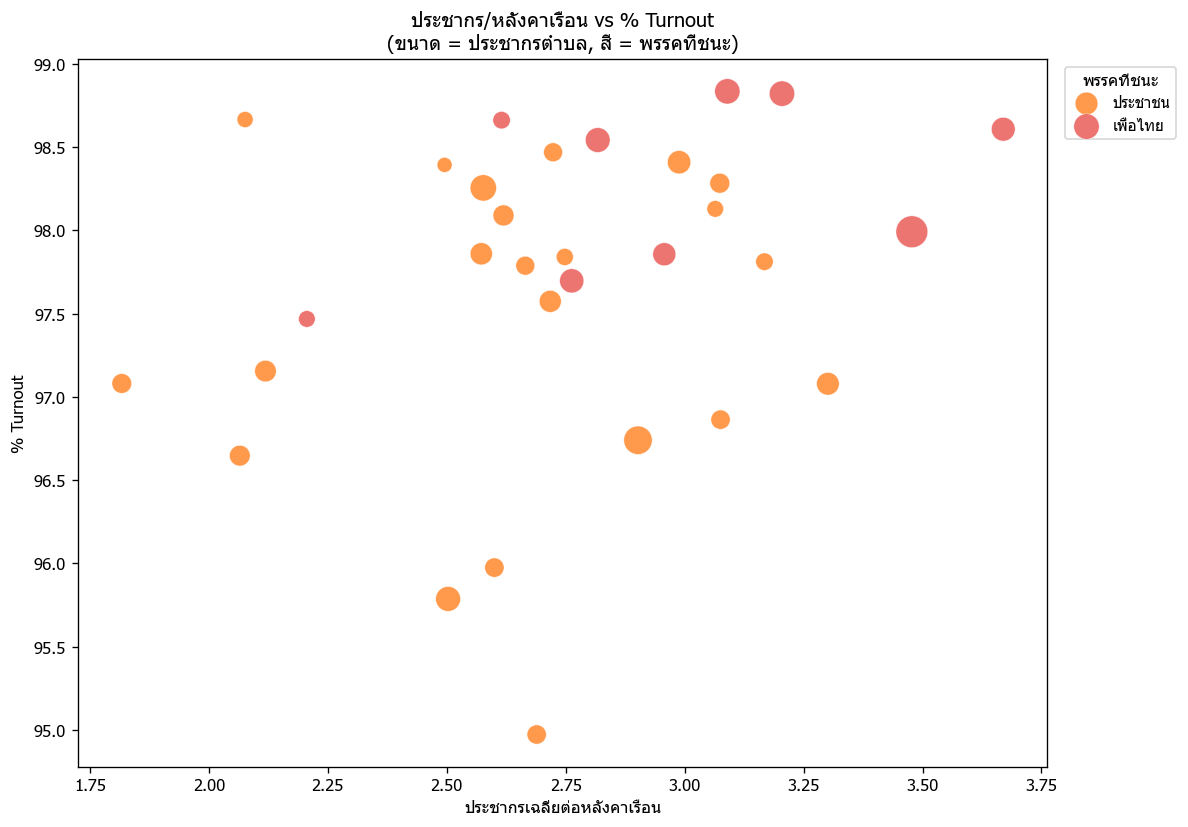

In [9]:
party_colors = {
    'ประชาชน':         '#FF6F00',
    'เพื่อไทย':        '#E53935',
    'กล้าธรรม':        '#00897B',
    'ประชาธิปัตย์':    '#1565C0',
    'ภูมิใจไทย':       '#6A1B9A',
    'รวมไทยสร้างชาติ': '#2E7D32',
}
default_color = '#9E9E9E'

plot_df = merged.dropna(subset=['pop_per_hh','turnout_pct'])

fig, ax = plt.subplots(figsize=(10, 7))
for party, grp in plot_df.groupby('winner_party'):
    color = party_colors.get(party, default_color)
    ax.scatter(grp['pop_per_hh'], grp['turnout_pct'],
               label=party, color=color,
               s=grp['pop_total']/30, alpha=0.7, edgecolors='white', linewidths=0.4)

ax.set_title('ประชากร/หลังคาเรือน vs % Turnout\n(ขนาด = ประชากรตำบล, สี = พรรคที่ชนะ)', fontsize=12)
ax.set_xlabel('ประชากรเฉลี่ยต่อหลังคาเรือน')
ax.set_ylabel('% Turnout')
ax.legend(title='พรรคที่ชนะ', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Scatter: จำนวนหมู่บ้าน vs % บัตรเสีย (สีตามพรรค)

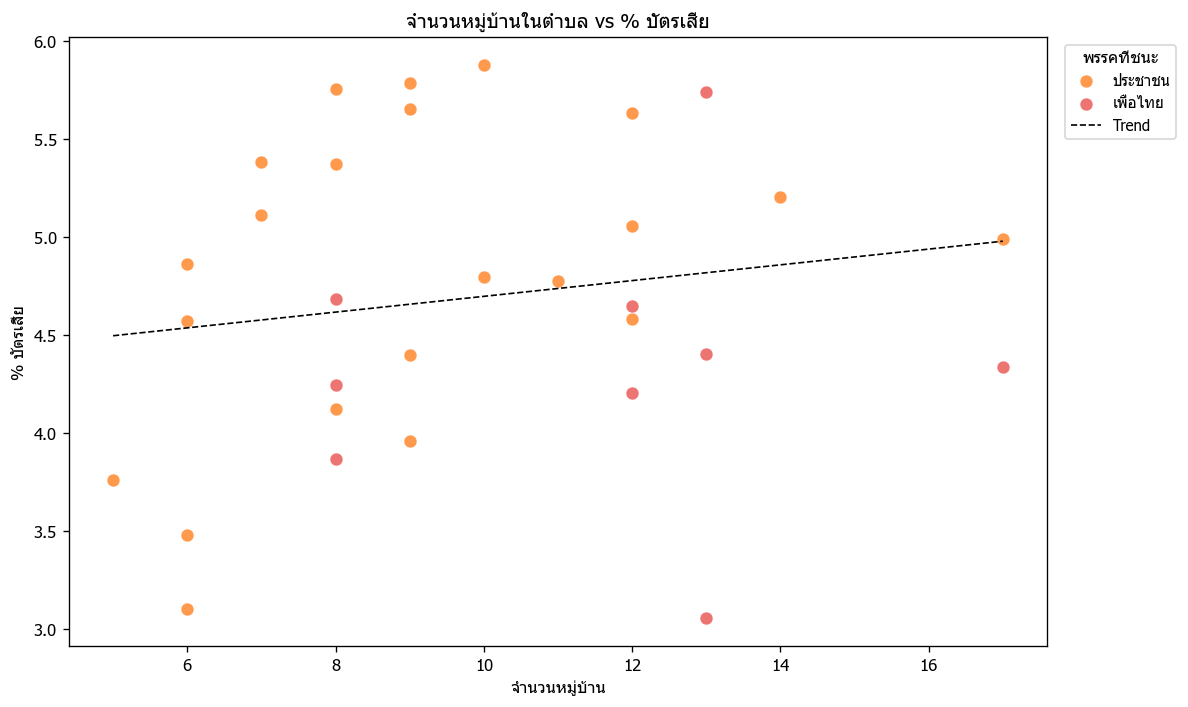

In [10]:
plot_df2 = merged.dropna(subset=['villages','invalid_pct'])

fig, ax = plt.subplots(figsize=(10, 6))
for party, grp in plot_df2.groupby('winner_party'):
    color = party_colors.get(party, default_color)
    ax.scatter(grp['villages'], grp['invalid_pct'],
               label=party, color=color,
               s=60, alpha=0.7, edgecolors='white', linewidths=0.4)

# trend line
z = np.polyfit(plot_df2['villages'], plot_df2['invalid_pct'], 1)
xr = np.linspace(plot_df2['villages'].min(), plot_df2['villages'].max(), 100)
ax.plot(xr, np.poly1d(z)(xr), 'k--', linewidth=1, label='Trend')

ax.set_title('จำนวนหมู่บ้านในตำบล vs % บัตรเสีย', fontsize=12)
ax.set_xlabel('จำนวนหมู่บ้าน')
ax.set_ylabel('% บัตรเสีย')
ax.legend(title='พรรคที่ชนะ', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Map — ตำบลทั่วลำปาง: สี = พรรคที่ชนะ, ขนาด = ประชากร

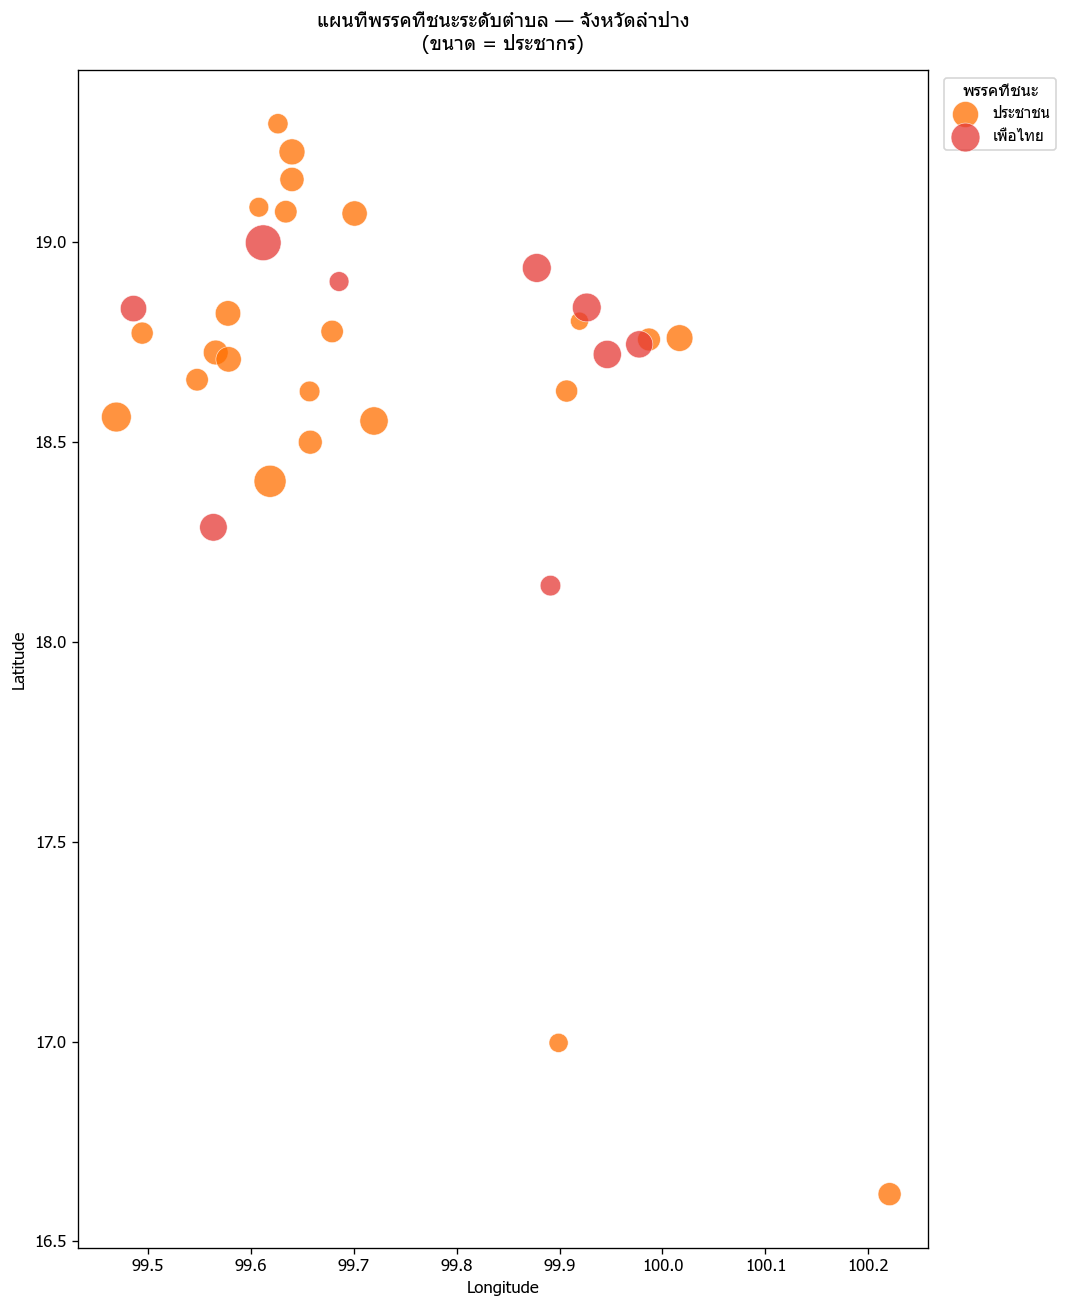

In [11]:
map_df = merged.dropna(subset=['lat','lon'])

fig, ax = plt.subplots(figsize=(9, 11))
for party, grp in map_df.groupby('winner_party'):
    color = party_colors.get(party, default_color)
    ax.scatter(
        grp['lon'], grp['lat'],
        label=party, color=color,
        s=grp['pop_total']/25 + 20,
        alpha=0.75, edgecolors='white', linewidths=0.4
    )

ax.set_title('แผนที่พรรคที่ชนะระดับตำบล — จังหวัดลำปาง\n(ขนาด = ประชากร)', fontsize=12, pad=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(title='พรรคที่ชนะ', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

## 11. สรุป: ลักษณะเฉลี่ยของตำบลที่เลือกแต่ละพรรค

In [12]:
profile_cols = ['pop_total','households','villages','dist_center_avg',
                'is_mountain','has_electricity','turnout_pct','invalid_pct','winner_pct']

profile = (
    merged[merged['winner_party'].isin(top_parties)]
    .groupby('winner_party')[profile_cols]
    .mean()
    .round(2)
    .sort_values('pop_total', ascending=False)
)
profile.columns = ['ประชากร','ครัวเรือน','หมู่บ้าน','ระยะห่างตัวเมือง(km)',
                   'พื้นที่ภูเขา','มีไฟฟ้า','Turnout%','บัตรเสีย%','% ที่ชนะ']
print('ลักษณะเฉลี่ยของตำบลแยกตามพรรคที่ชนะ:')
profile

ลักษณะเฉลี่ยของตำบลแยกตามพรรคที่ชนะ:


,ประชากร,ครัวเรือน,หมู่บ้าน,ระยะห่างตัวเมือง(km),พื้นที่ภูเขา,มีไฟฟ้า,Turnout%,บัตรเสีย%,% ที่ชนะ
winner_party,,,,,,,,,
เพื่อไทย,6225.78,2051.22,11.56,18.59,0.11,0.02,98.28,4.35,27.05
ประชาชน,4683.26,1818.96,9.22,14.52,0.09,0.00,97.45,4.83,27.82


In [13]:
# Export
merged.to_csv(OUT / 'tambon_socioeconomic_election.csv', index=False, encoding='utf-8-sig')
profile.to_csv(OUT / 'party_profile_by_tambon.csv', encoding='utf-8-sig')
print('Saved:')
for f in sorted(OUT.glob('*.csv')):
    print(f'  socioeconomic_data/{f.name}')

Saved:
  socioeconomic_data/party_profile_by_tambon.csv
  socioeconomic_data/tambon_socioeconomic_election.csv
